In [ ]:
import pandas as pd
import requests
import numpy as np
import random
from urllib.parse import quote
from concurrent.futures import ThreadPoolExecutor, as_completed
# import time

import plotly.express as px 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import euclidean_distances
from scipy.spatial.distance import cdist

# Set to False if you have already made the parquet file.
extract_json = False

## Download the Artist JSON File

1. Go to the following link: https://data.metabrainz.org/pub/musicbrainz/data/json-dumps/
2. Download the most recent JSON dump.
3. Extract the tar file into the `artists/` subfolder.

## Extract the Artist Names from the JSON File

In [2]:
if extract_json:
    import ijson

    file = "artists/artist.json"
    prefix = "name"
    artist_list = []

    with open(file, 'rb') as f:
        parser = ijson.items(f, prefix, multiple_values=True)
        artist_list = [item for item in parser]

## Export the Artist Names as a Parquet File for Future Work

In [3]:
if extract_json:
    len(artist_list)
    df = pd.DataFrame(artist_list)
    df = df[0].drop_duplicates()
    df.to_parquet('artists/artists.parquet', engine='pyarrow', compression='snappy')

## Retrieve Artist IDs from ReccoBeats

In [ ]:
artists = pd.read_parquet("artists/artists.parquet")
artist_list = artists.iloc[:, 0].values
artist_list_len = len(artist_list)

max_n = 30
id_list = []
random_samples = random.sample(range(0, artist_list_len), max_n)
max_workers = 10

headers = {
    'Accept': 'application/json'
}

def fetch_artist(artist):
    url = f"https://api.reccobeats.com/v1/artist/search?searchText={quote(str(artist))}"
    # start = time.time()
    response = session.get(url)
    # print(time.time() - start)
    response.raise_for_status()
    return response.json().get('content', [])

with requests.Session() as session:
    session.headers.update(headers)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(fetch_artist, artist_list[idx])
            for idx in random_samples
        ]

        for future in as_completed(futures):
            id_list.extend(future.result())

In [5]:
artist_df = pd.DataFrame(id_list)

## Retrieve Track IDs

In [6]:
track_list = []

for id in artist_df['id']:

    url = f"https://api.reccobeats.com/v1/artist/{id}/track"

    payload = {}
    headers = {
        'Accept': 'application/json'
    }

    response = requests.request("GET", url, headers=headers, data=payload)
    tracks = response.json()['content']

    for track in tracks:
        track_list.append(track)

In [ ]:
track_df = pd.DataFrame(track_list)
num_tracks = len(track_df)
divisions = num_tracks // 40
remainder = num_tracks % 40
print(num_tracks)
print(divisions)

## Get Track's Audio Features

In [8]:
div = 0
feature_list = []
for i in range(0, divisions):
    if i == divisions - 1:
        track_ids = track_df['id'][div: div + remainder]
    else:
        track_ids = track_df['id'][div: div + 40]
    
    id_string = ",".join(track_ids)

    url = f"https://api.reccobeats.com/v1/audio-features?ids={id_string}"
    payload = {}
    headers = {
        'Accept': 'application/json'
    }

    response = requests.request("GET", url, headers=headers, data=payload)
    features = response.json()["content"]

    for feature in features:
        feature_list.append(feature)
    
    
    div += 40

In [9]:
feature_df = pd.DataFrame(feature_list)

In [10]:
df = pd.merge(track_df, feature_df, on=["id", "href", "isrc"], how="inner")

In [11]:
# from yellowbrick.target import FeatureCorrelation

# feature_names = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 
#                  'speechiness', 'tempo', 'valence','key','mode']

# X, y = df[feature_names], df['popularity']

# # Create a list of the feature names
# features = np.array(feature_names)

# # Instantiate the visualizer
# visualizer = FeatureCorrelation(labels=features)

# plt.rcParams['figure.figsize']=(20,20)
# # visualizer.fit(X, y)
# visualizer.show()

In [ ]:
song_cluster_pipeline = Pipeline(
    [
        ('scaler', StandardScaler()), 
        ('kmeans', KMeans(n_clusters=5, verbose=False))
    ], 
    verbose=False
)
X = df.select_dtypes(np.number).fillna(0)
number_cols = list(X.columns)
song_cluster_pipeline.fit(X)
song_cluster_labels = song_cluster_pipeline.predict(X)
df['cluster_label'] = song_cluster_labels

In [ ]:
from sklearn.decomposition import PCA

pca_pipeline = Pipeline([('scaler', StandardScaler()), ('PCA', PCA(n_components=2))])
song_embedding = pca_pipeline.fit_transform(X)
projection = pd.DataFrame(columns=['x', 'y'], data=song_embedding)
projection['title'] = df['trackTitle']
projection['artists'] = df['artists']
projection['cluster'] = df['cluster_label']

fig = px.scatter(
    projection, x='x', y='y', color='cluster', hover_data=['title'])
fig.show()

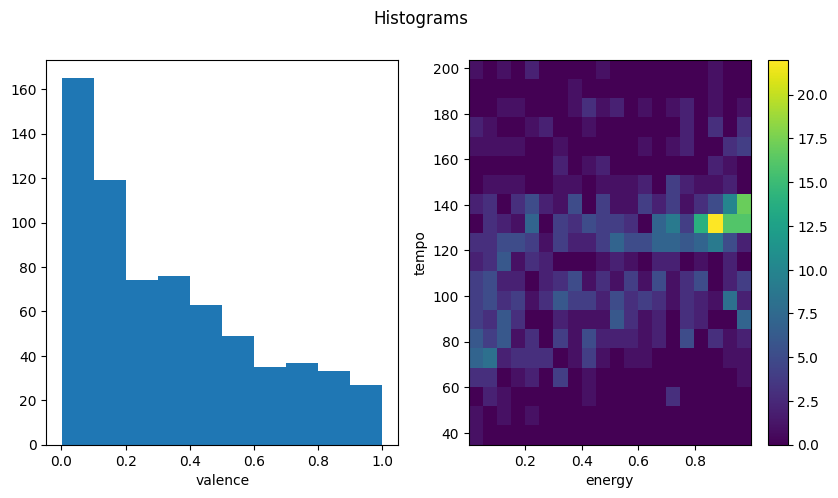

In [19]:
x = "energy"
y = "tempo"

X = df[x].fillna(0)
Y = df[y].fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=False, sharex=False, figsize=(10, 5))
fig.suptitle("Histograms")
h = ax2.hist2d(X, Y, bins=20)
ax1.hist(df["valence"])

ax2.set_xlabel(x)
ax2.set_ylabel(y)

ax1.set_xlabel("valence")

plt.colorbar(h[3], ax=ax2)

plt.show()

